# 🏨 EDA02 - Hotel Operations Analysis

## Project Overview

The hospitality industry relies heavily on understanding booking patterns, customer behavior, and revenue trends to deliver exceptional guest experiences and maximize operational efficiency. This project performs an Exploratory Data Analysis (EDA) on the Hotel Booking Demand dataset to identify booking trends, cancellation patterns, guest preferences, and revenue opportunities.

The analysis aims to provide meaningful insights that can help hotel management optimize room occupancy, reduce booking cancellations, improve customer satisfaction, and enhance revenue management strategies.

---

## Problem Statement

Elite Hotels International operates multiple hotels across different locations and faces challenges in managing booking patterns and improving guest satisfaction. By analyzing historical booking data, the company aims to understand customer behavior, identify factors influencing cancellations, optimize pricing strategies, and improve overall operational performance.

---

## Objectives

- Perform data cleaning and preprocessing.
- Analyze hotel booking patterns.
- Study cancellation trends and their influencing factors.
- Examine guest demographics and booking behavior.
- Analyze Average Daily Rate (ADR) and revenue trends.
- Identify seasonal booking patterns.
- Generate actionable insights to support business decision-making.

---

## Stakeholders

### Internal Stakeholders

- Management Team
- Operations Team
- Marketing Team
- Customer Service Team

### External Stakeholders

- Hotel Guests
- Travel Agencies
- Suppliers

---

## Dataset Information

**Dataset Name:** Hotel Booking Demand Dataset

**Source:** Kaggle

The dataset contains booking information including hotel type, booking dates, guest demographics, market segments, booking channels, room types, cancellations, and revenue-related information.

In [33]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_style("whitegrid")

# Create Images folder
os.makedirs("Images2", exist_ok=True)

# Function to save plots
def save_plot(filename):
    plt.savefig(f"Images2/{filename}.png", dpi=300, bbox_inches="tight")

In [4]:
df = pd.read_csv("hotel_bookings.csv")

# Data Understanding

Before performing exploratory data analysis, it is important to understand the structure and quality of the dataset. This section examines the dataset's dimensions, data types, statistical summary, missing values, duplicate records, and unique values to identify the preprocessing steps required before analysis.

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.shape

(119390, 32)

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [11]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [12]:
(df.isnull().sum()/len(df))*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [13]:
df.duplicated().sum()

np.int64(31994)

In [14]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [15]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [16]:
df.sample(5, random_state=42)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30946,Resort Hotel,0,203,2016,December,49,2,2,5,2,...,No Deposit,250.0,NaN,0,Transient,66.8,0,0,Check-Out,2016-12-09
40207,City Hotel,1,82,2015,July,29,16,0,3,2,...,No Deposit,9.0,NaN,0,Transient,76.5,0,0,Canceled,2015-07-16
103708,City Hotel,0,25,2016,December,53,27,0,3,3,...,No Deposit,220.0,NaN,0,Transient-Party,60.0,0,1,Check-Out,2016-12-30
85144,City Hotel,0,1,2016,March,11,9,0,1,1,...,No Deposit,9.0,NaN,0,Transient-Party,95.0,0,0,Check-Out,2016-03-10
109991,City Hotel,0,70,2017,April,16,16,2,2,2,...,No Deposit,9.0,NaN,0,Transient,108.0,0,0,Check-Out,2017-04-20


# Data Cleaning and Preprocessing

Data cleaning is an essential step in the data analysis process to ensure accurate and reliable results. The Hotel Booking Demand dataset contains missing values, duplicate records, and columns that require data type conversion before analysis.

In this section, missing values are handled appropriately, duplicate records are removed, date columns are converted into datetime format, and the dataset is prepared for exploratory data analysis.

In [17]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [18]:
df.duplicated().sum()

np.int64(31994)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 87396
Number of Columns : 32


In [22]:
df['company'].fillna(0, inplace=True)

df['agent'].fillna(0, inplace=True)

df['children'].fillna(0, inplace=True)

In [23]:
df.isnull().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            0
babies                              0
meal                                0
country                           452
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
agent                               0
company                             0
days_in_waiting_list                0
customer_typ

In [24]:
df['country'].fillna('Unknown', inplace=True)

In [25]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [26]:
# Convert Reservation Status Date to Datetime

df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [27]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

# Data Type Conversion

Several columns require conversion into appropriate data types before analysis. Converting date columns and ensuring numerical columns have the correct data types improves the accuracy of calculations and visualizations.

In [28]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [29]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand booking patterns, customer behavior, hotel performance, cancellation trends, and revenue metrics. This section answers the business questions provided in the case study using statistical analysis and visualizations to generate actionable insights for hotel management.

In [30]:
# Question 1: Average Lead Time for Bookings

average_lead_time = df['lead_time'].mean()

print(f"Average Lead Time : {average_lead_time:.2f} days")

Average Lead Time : 79.89 days


In [31]:
# Question 2: Distribution of Bookings by Hotel Type

hotel_type = df['hotel'].value_counts()

hotel_type

hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

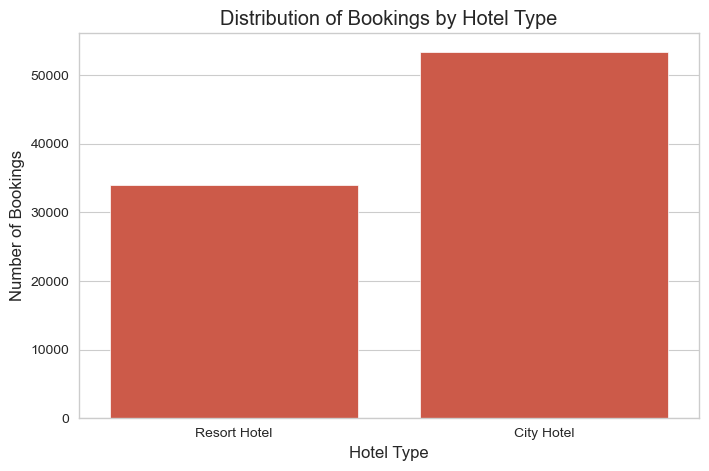

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='hotel')

plt.title("Distribution of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

save_plot("distribution_of_bookings_by_hotel_type")

plt.show()

In [35]:
# Question 3: Total Canceled Bookings

cancelled_bookings = df['is_canceled'].sum()

print(f"Total Cancelled Bookings : {cancelled_bookings}")

Total Cancelled Bookings : 24025


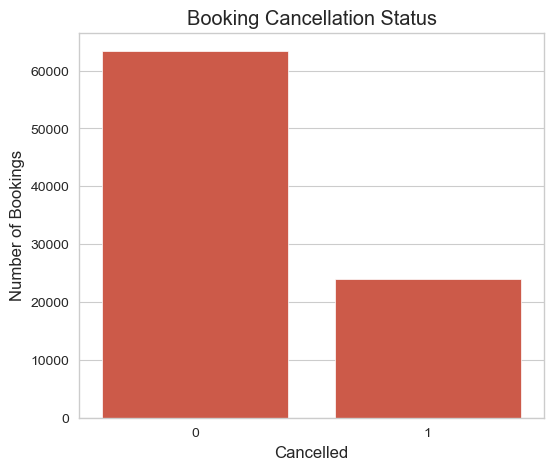

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='is_canceled')

plt.title("Booking Cancellation Status")
plt.xlabel("Cancelled")
plt.ylabel("Number of Bookings")

save_plot("booking_cancellation_status")

plt.show()

In [37]:
# Question 4: Most Common Arrival Month

arrival_month = df['arrival_date_month'].value_counts()

arrival_month

arrival_date_month
August       11257
July         10057
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64

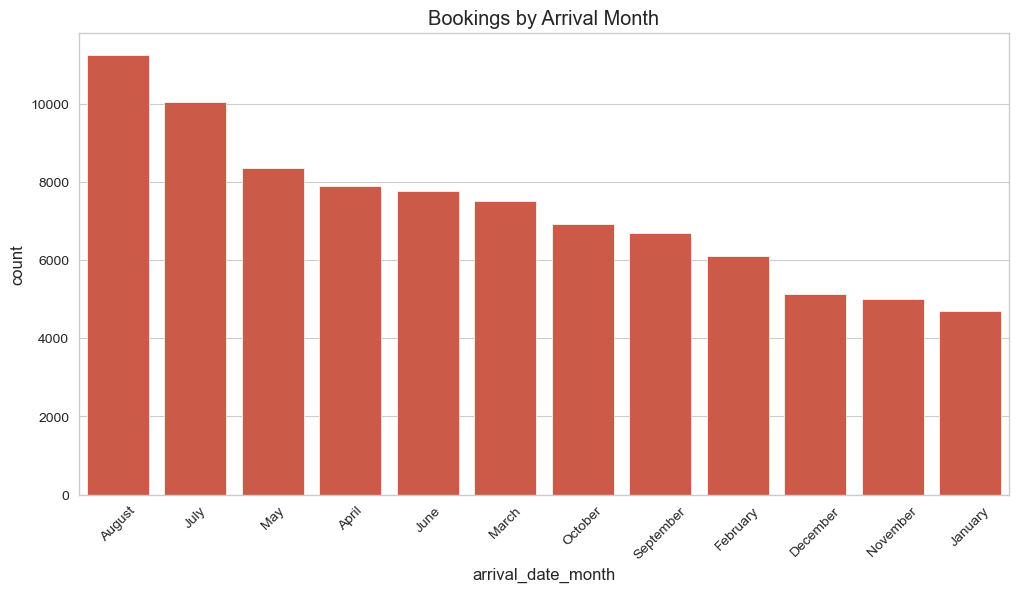

In [38]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='arrival_date_month',
    order=df['arrival_date_month'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Bookings by Arrival Month")

save_plot("bookings_by_arrival_month")

plt.show()

In [39]:
# Question 5: Average Special Requests

average_requests = df['total_of_special_requests'].mean()

print(f"Average Special Requests : {average_requests:.2f}")

Average Special Requests : 0.70


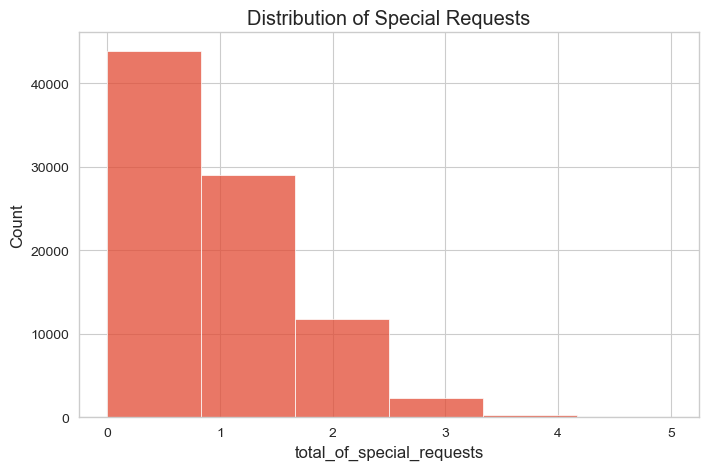

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['total_of_special_requests'],
    bins=6
)

plt.title("Distribution of Special Requests")

save_plot("distribution_of_special_requests")

plt.show()

In [41]:
# Question 6: Country with Highest Bookings

country_booking = df['country'].value_counts().head(10)

country_booking

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

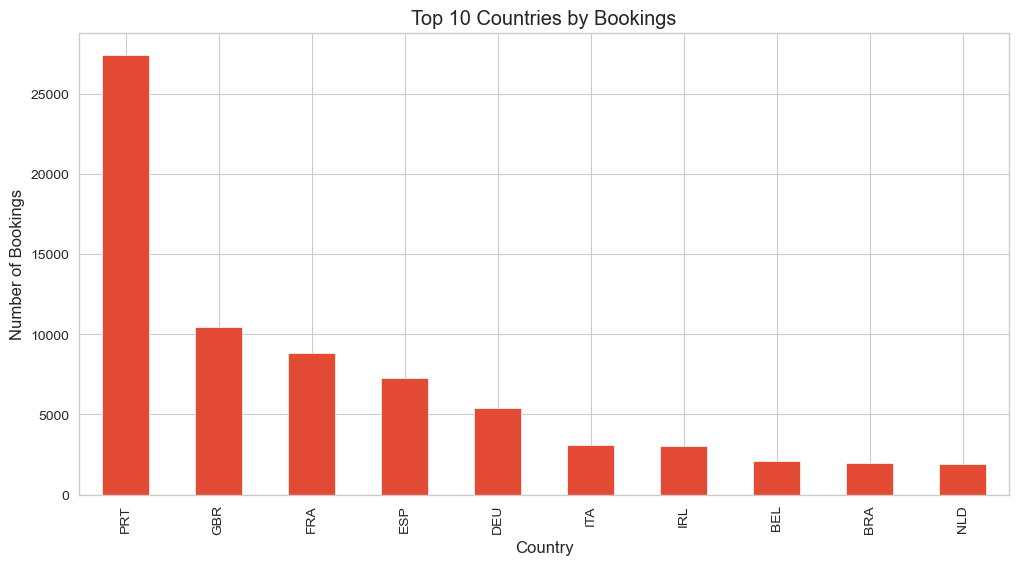

In [42]:
plt.figure(figsize=(12,6))

country_booking.plot(kind='bar')

plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")

save_plot("top_10_countries_by_bookings")

plt.show()

In [43]:
# Question 7: Average ADR by Hotel Type

adr_hotel = df.groupby('hotel')['adr'].mean()

adr_hotel

hotel
City Hotel      110.985944
Resort Hotel     99.025346
Name: adr, dtype: float64

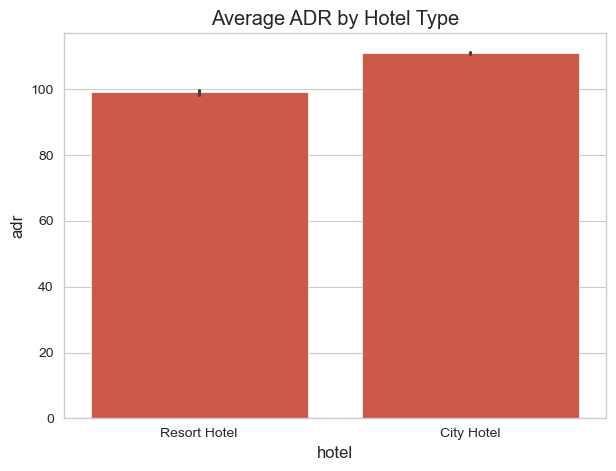

In [44]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='hotel',
    y='adr',
    estimator='mean'
)

plt.title("Average ADR by Hotel Type")

save_plot("average_adr_by_hotel_type")

plt.show()

In [45]:
# Question 8: Percentage of Guests Requiring Parking

parking_percentage = (
    (df['required_car_parking_spaces'] > 0).mean()
) * 100

print(f"Parking Requirement : {parking_percentage:.2f}%")

Parking Requirement : 8.37%


In [46]:
# Question 9: Average Stay Duration

average_weekday = df['stays_in_week_nights'].mean()

average_weekend = df['stays_in_weekend_nights'].mean()

print("Average Week Nights :", round(average_weekday,2))

print("Average Weekend Nights :", round(average_weekend,2))

Average Week Nights : 2.63
Average Weekend Nights : 1.01


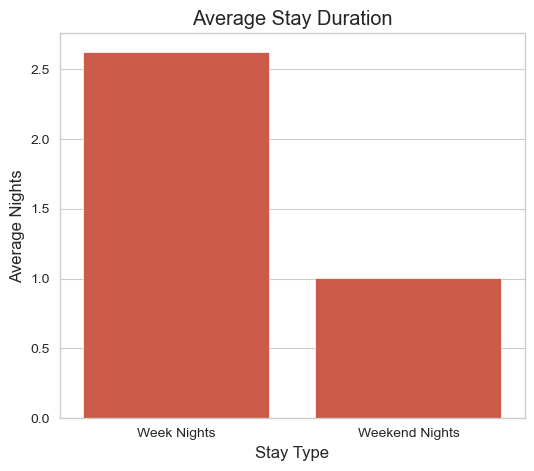

In [47]:
stay_duration = pd.DataFrame({
    'Stay Type':['Week Nights','Weekend Nights'],
    'Average Nights':[average_weekday,average_weekend]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=stay_duration,
    x='Stay Type',
    y='Average Nights'
)

plt.title("Average Stay Duration")

save_plot("average_stay_duration")

plt.show()

In [48]:
# Question 10: Bookings Through Travel Agents

agent_booking = (df['agent'] != 0).sum()

print(f"Bookings Through Travel Agents : {agent_booking}")

Bookings Through Travel Agents : 75203


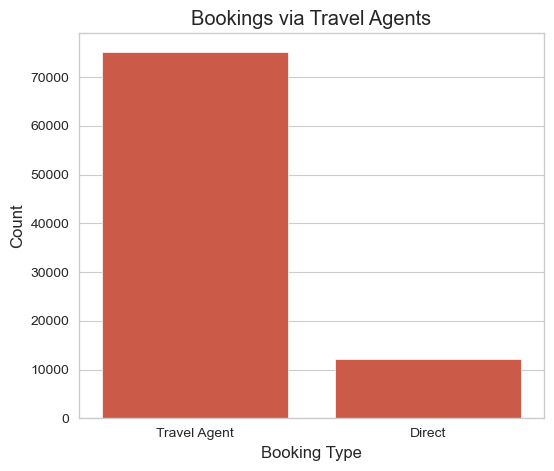

In [49]:
agent_data = pd.DataFrame({
    'Booking Type':['Travel Agent','Direct'],
    'Count':[agent_booking,(df['agent']==0).sum()]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=agent_data,
    x='Booking Type',
    y='Count'
)

plt.title("Bookings via Travel Agents")

save_plot("bookings_via_travel_agents")

plt.show()

In [50]:
# Question 11: Cancellation Rate by Hotel Type

cancellation_rate = df.groupby('hotel')['is_canceled'].mean() * 100

print(cancellation_rate)

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64


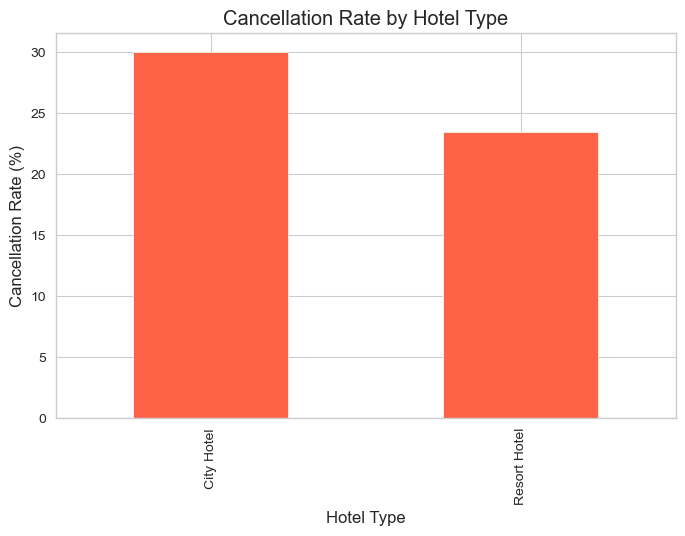

In [51]:
plt.figure(figsize=(8,5))

cancellation_rate.plot(kind='bar', color='tomato')

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

save_plot("cancellation_rate_by_hotel_type")

plt.show()

In [52]:
# Question 12: Bookings by Market Segment

market_segment = df['market_segment'].value_counts()

market_segment

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

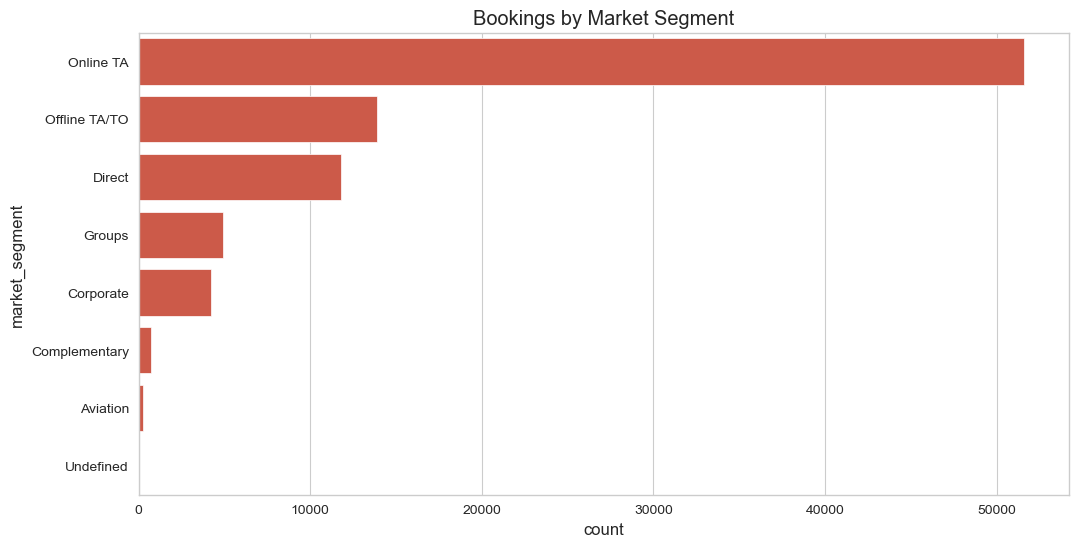

In [53]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.title("Bookings by Market Segment")

save_plot("bookings_by_market_segment")

plt.show()

In [54]:
# Question 13: Distribution Channel Analysis

distribution = df['distribution_channel'].value_counts()

distribution

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

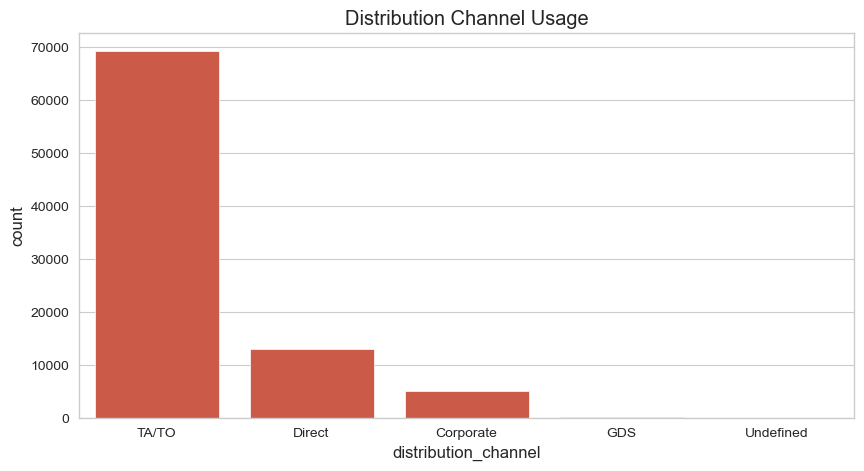

In [55]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='distribution_channel',
    order=df['distribution_channel'].value_counts().index
)

plt.title("Distribution Channel Usage")

save_plot("distribution_channel_usage")

plt.show()

In [56]:
# Question 14: Average ADR by Market Segment

market_adr = df.groupby('market_segment')['adr'].mean().sort_values(ascending=False)

market_adr

market_segment
Online TA        118.171606
Direct           116.579429
Aviation         100.170396
Offline TA/TO     81.764191
Groups            74.864284
Corporate         68.151246
Undefined         15.000000
Complementary      3.049245
Name: adr, dtype: float64

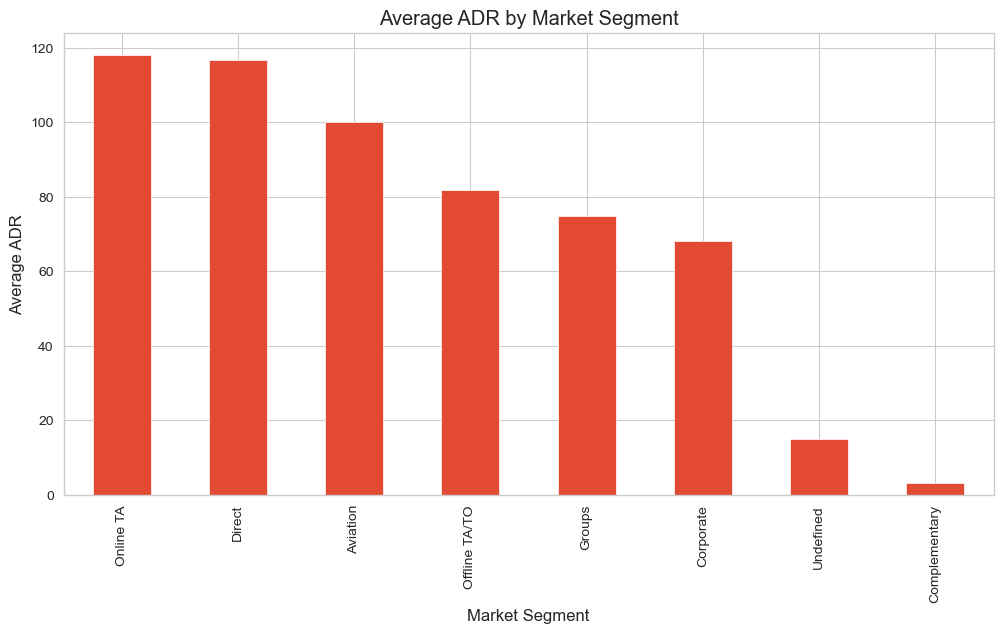

In [57]:
plt.figure(figsize=(12,6))

market_adr.plot(kind='bar')

plt.title("Average ADR by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average ADR")

save_plot("average_adr_by_market_segment")

plt.show()

In [58]:
# Question 15: Customer Type Analysis

customer_type = df['customer_type'].value_counts()

customer_type

customer_type
Transient          71986
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64

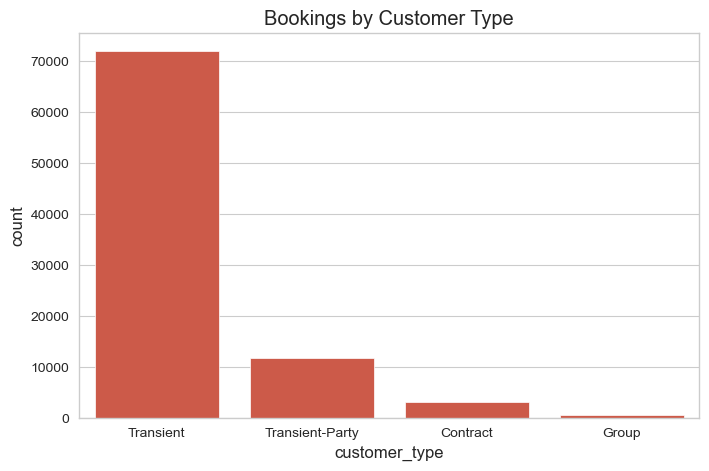

In [59]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='customer_type',
    order=df['customer_type'].value_counts().index
)

plt.title("Bookings by Customer Type")

save_plot("bookings_by_customer_type")

plt.show()

In [60]:
# Question 16: Most Reserved Room Type

room_type = df['reserved_room_type'].value_counts()

room_type

reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64

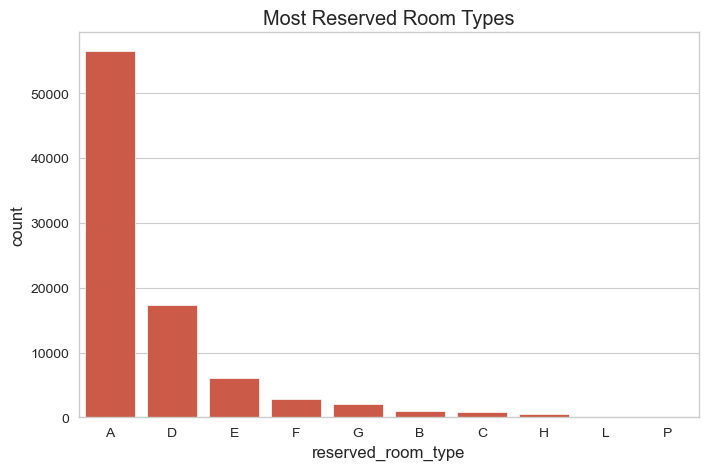

In [61]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='reserved_room_type',
    order=df['reserved_room_type'].value_counts().index
)

plt.title("Most Reserved Room Types")

save_plot("most_reserved_room_types")

plt.show()

In [62]:
# Question 17: Reserved Room Type vs Assigned Room Type

room_comparison = pd.crosstab(
    df['reserved_room_type'],
    df['assigned_room_type']
)

room_comparison

assigned_room_type,A,B,C,D,E,F,G,H,I,K,L,P
reserved_room_type,,,,,,,,,,,,
A,45879,894,1256,6410,1035,390,178,94,209,207,0,0
B,106,874,0,5,2,2,8,0,0,2,0,0
C,5,2,867,6,4,2,10,9,10,0,0,0
D,296,27,33,15984,657,199,82,9,67,44,0,0
E,15,3,6,22,5462,383,98,4,40,16,0,0
F,6,17,0,4,31,2636,113,3,10,3,0,0
G,5,2,2,0,4,14,1999,7,15,4,0,0
H,0,0,0,1,0,0,10,579,6,0,0,0
L,1,1,1,0,0,1,0,1,0,0,1,0


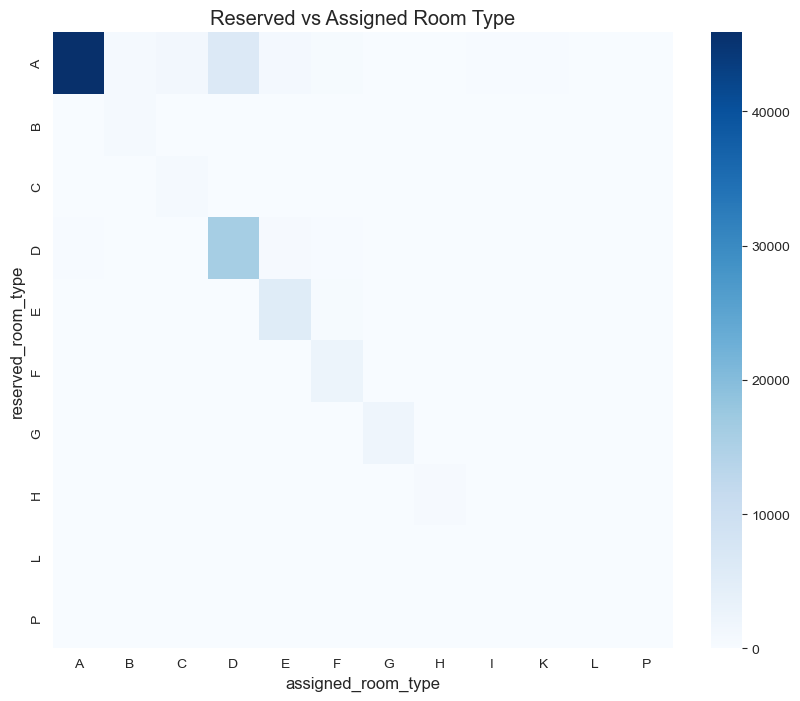

In [63]:
plt.figure(figsize=(10,8))

sns.heatmap(room_comparison, cmap='Blues')

plt.title("Reserved vs Assigned Room Type")

save_plot("reserved_vs_assigned_room_type")

plt.show()

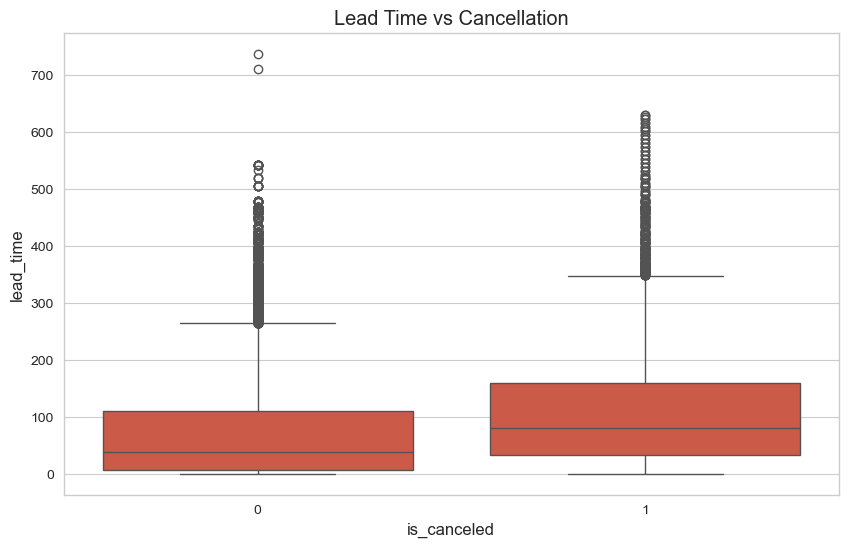

In [64]:
# Question 18: Lead Time vs Cancellation

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='is_canceled',
    y='lead_time'
)

plt.title("Lead Time vs Cancellation")

save_plot("lead_time_vs_cancellation")

plt.show()

In [65]:
# Question 19: Highest Average Daily Rate

highest_adr = df.groupby('hotel')['adr'].mean().sort_values(ascending=False)

highest_adr

hotel
City Hotel      110.985944
Resort Hotel     99.025346
Name: adr, dtype: float64

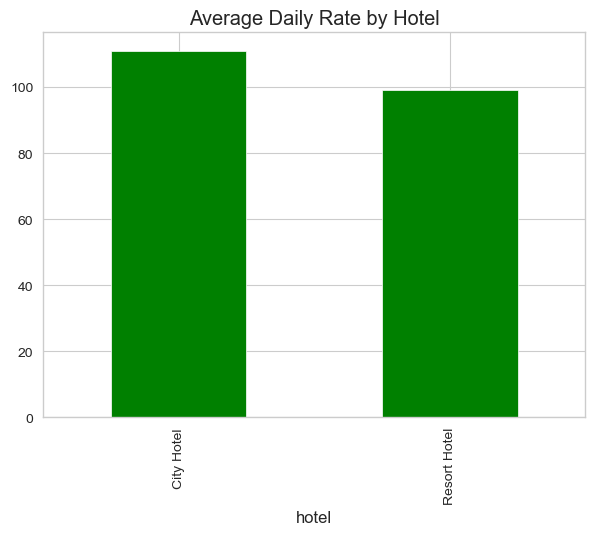

In [66]:
plt.figure(figsize=(7,5))

highest_adr.plot(kind='bar', color='green')

plt.title("Average Daily Rate by Hotel")

save_plot("highest_average_daily_rate")

plt.show()

In [67]:
# Question 20: Monthly Cancellation Trend

monthly_cancel = df.groupby('arrival_date_month')['is_canceled'].sum()

monthly_cancel

arrival_date_month
April        2409
August       3623
December     1378
February     1415
January      1038
July         3198
June         2354
March        1830
May          2442
November     1054
October      1642
September    1642
Name: is_canceled, dtype: int64

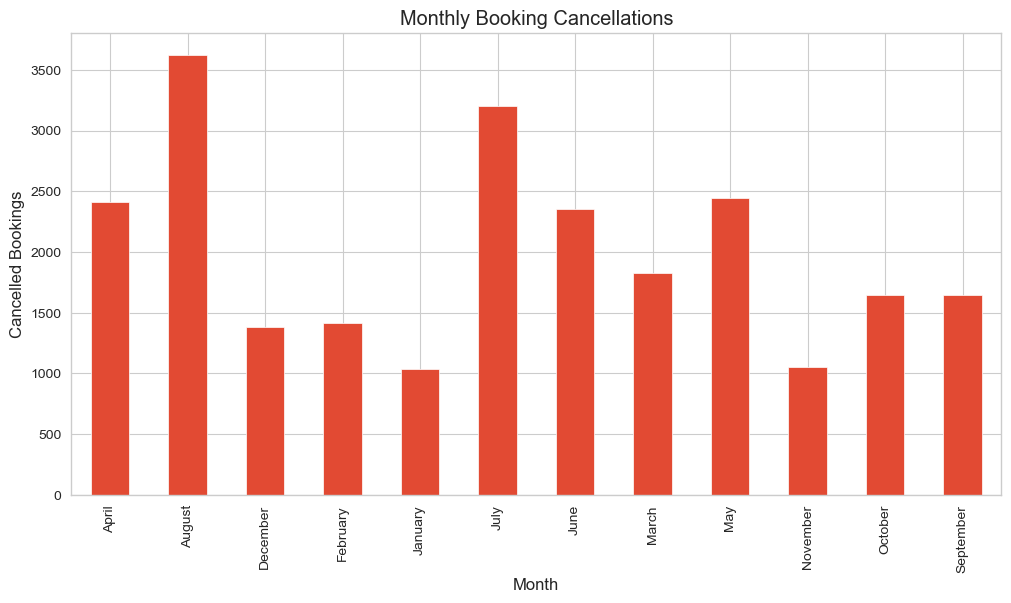

In [68]:
plt.figure(figsize=(12,6))

monthly_cancel.plot(kind='bar')

plt.title("Monthly Booking Cancellations")
plt.xlabel("Month")
plt.ylabel("Cancelled Bookings")

save_plot("monthly_booking_cancellations")

plt.show()

In [69]:
# Question 21: Countries with Highest Cancellation Rates

country_cancel = (
    df.groupby('country')['is_canceled']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    * 100
)

country_cancel

country
MYT    100.0
VGB    100.0
JEY    100.0
KHM    100.0
BEN    100.0
GLP    100.0
UMI    100.0
HND    100.0
IMN    100.0
NIC    100.0
Name: is_canceled, dtype: float64

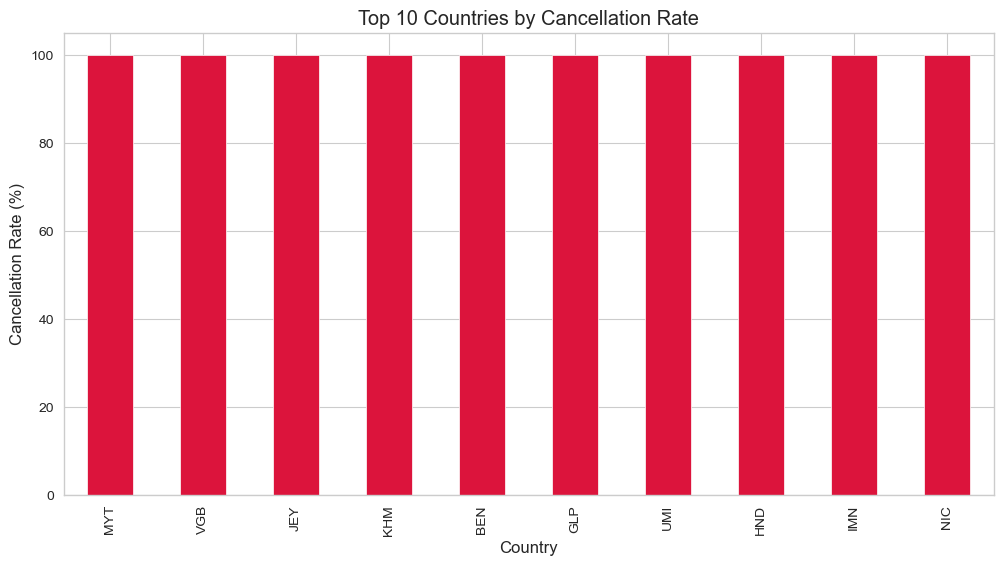

In [70]:
plt.figure(figsize=(12,6))

country_cancel.plot(kind='bar', color='crimson')

plt.title("Top 10 Countries by Cancellation Rate")
plt.xlabel("Country")
plt.ylabel("Cancellation Rate (%)")

save_plot("top_10_countries_by_cancellation_rate")

plt.show()

In [71]:
# Question 22: Booking Patterns by Hotel Type

hotel_pattern = pd.crosstab(
    df['arrival_date_month'],
    df['hotel']
)

hotel_pattern

hotel,City Hotel,Resort Hotel
arrival_date_month,,
April,5080,2828
August,6591,4666
December,3014,2117
February,3605,2493
January,2730,1963
July,5744,4313
June,5005,2760
March,4856,2657
May,5413,2942


<Figure size 1400x600 with 0 Axes>

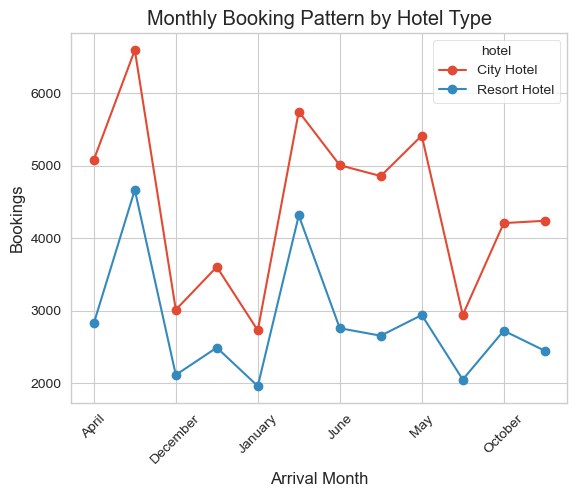

In [72]:
plt.figure(figsize=(14,6))

hotel_pattern.plot(kind='line', marker='o')

plt.title("Monthly Booking Pattern by Hotel Type")
plt.xlabel("Arrival Month")
plt.ylabel("Bookings")
plt.xticks(rotation=45)

save_plot("monthly_booking_pattern_by_hotel_type")

plt.show()

In [73]:
# Question 23: Special Requests vs Cancellation

special_request = pd.crosstab(
    df['total_of_special_requests'],
    df['is_canceled']
)

special_request

is_canceled,0,1
total_of_special_requests,,
0,29320,14574
1,22514,6503
2,9297,2515
3,1920,397
4,286,34
5,34,2


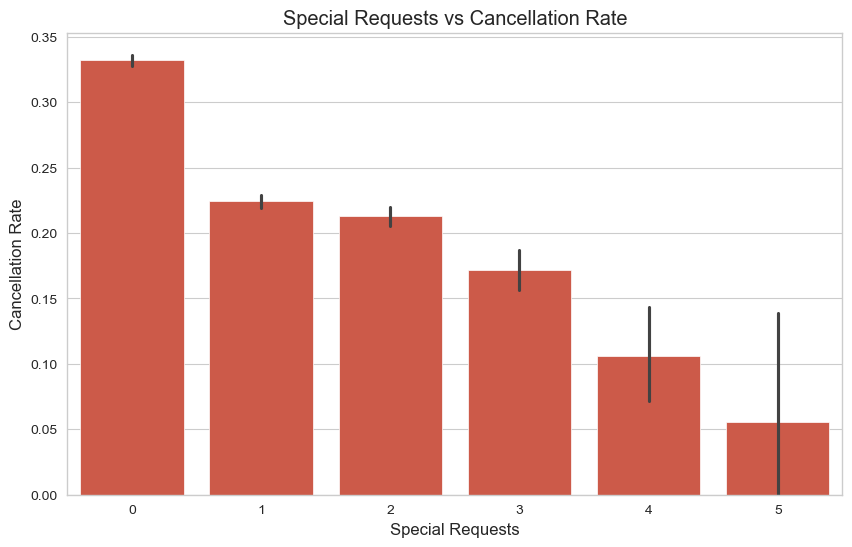

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='total_of_special_requests',
    y='is_canceled',
    estimator=np.mean
)

plt.title("Special Requests vs Cancellation Rate")
plt.xlabel("Special Requests")
plt.ylabel("Cancellation Rate")

save_plot("special_requests_vs_cancellation_rate")

plt.show()

In [75]:
# Question 24: ADR by Customer Type and Market Segment

adr_analysis = df.pivot_table(
    values='adr',
    index='customer_type',
    columns='market_segment',
    aggfunc='mean'
)

adr_analysis

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
customer_type,,,,,,,,
Contract,NaN,4.200000,50.533333,59.285714,70.310635,80.417410,110.797267,NaN
Group,110.000000,13.166667,82.828571,98.370769,52.281538,76.482813,87.411214,NaN
Transient,100.256842,2.476947,66.483223,117.565524,77.851819,80.357894,119.110630,NaN
Transient-Party,97.812500,14.000000,73.125804,107.847165,74.316639,86.910042,107.552612,15.0


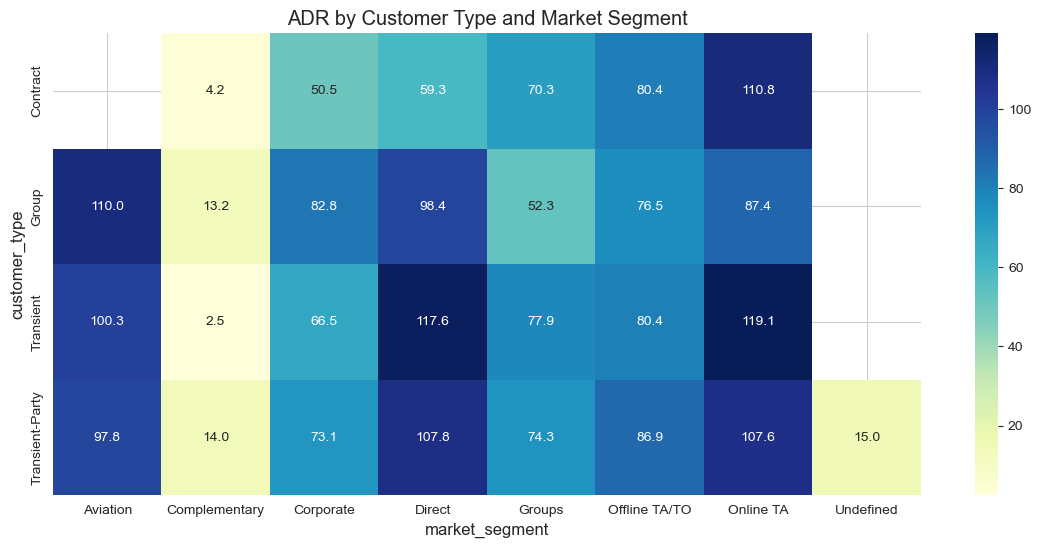

In [76]:
plt.figure(figsize=(14,6))

sns.heatmap(
    adr_analysis,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("ADR by Customer Type and Market Segment")

save_plot("adr_by_customer_type_and_market_segment")

plt.show()

In [77]:
# Question 25: Correlation of Numerical Features with Booking Cancellation

correlation = df.corr(numeric_only=True)

correlation['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
agent                            -0.000900
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
company                          -0.074758
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64

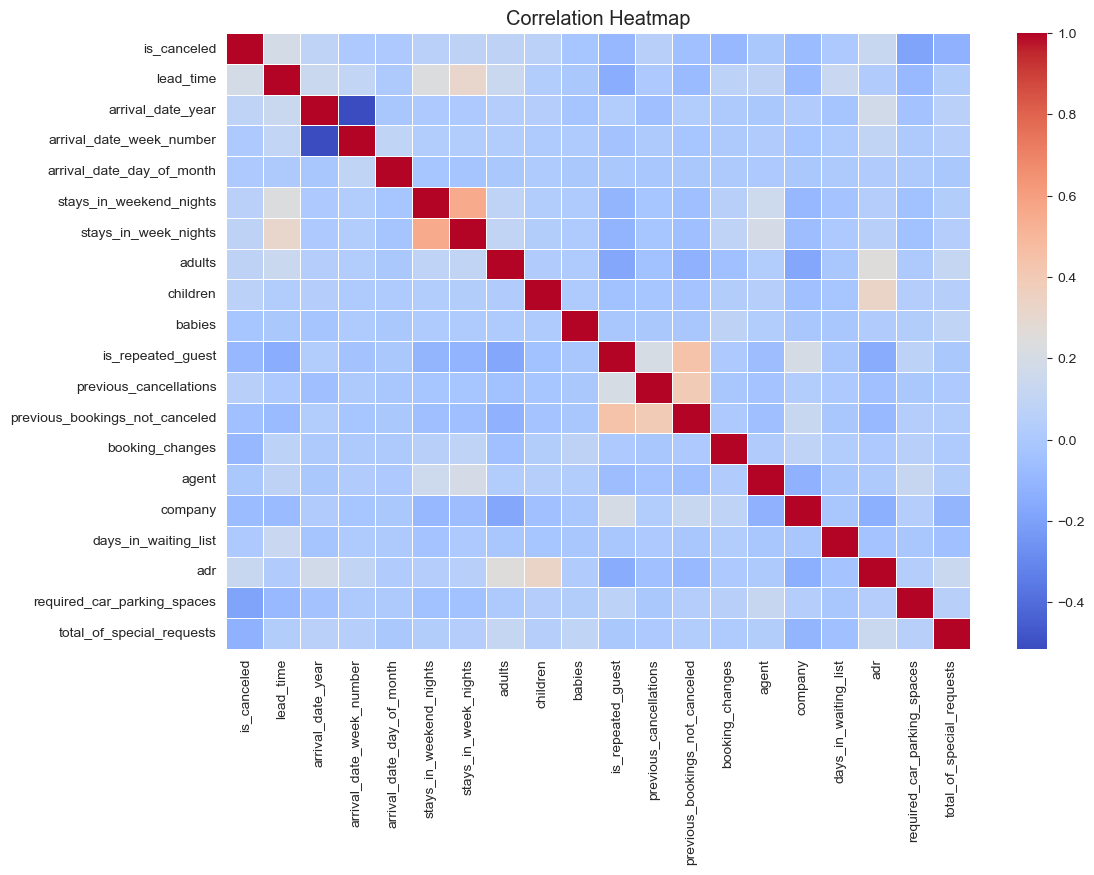

In [78]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

save_plot("correlation_heatmap")

plt.show()

In [80]:
# Correlation with Booking Cancellation

correlation = df.corr(numeric_only=True)

correlation['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
agent                            -0.000900
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
company                          -0.074758
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64